In [ ]:
import pandas as pd
import sklearn as sk
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.feature_selection import chi2, SelectKBest, VarianceThreshold, RFE, SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor

# Reducción de dimensionalidad

In [ ]:
diabetes = load_diabetes()
df = pd.DataFrame(data=diabetes.data, columns=['age', 'sex', 'body_mass_index', 'average_blood_pressure', 's1', 's2', 's3', 's4', 's5', 's6'])
df["disease_progression"] = diabetes.target

df
# Ten baseline variables: age, sex, body mass index, average blood pressure, and six blood serum measurements
# were obtained for each of 442 diabetes patients, as well as the response of interest, a quantitative measure
# of disease progression one year after baseline.

,age,sex,body_mass_index,average_blood_pressure,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


## Eliminar columnas con datos faltantes

In [ ]:
df.dropna(axis='columns')
# how='any' --> algún valor NA / 'all' todos los valores son NA
# thresh=10 --> 10 valores no-NA por lo menos

In [ ]:
for c in df.columns:
    print(c, df[c].isna().sum())
    if df[c].isna().sum() / df.shape[0] > 0.6: # 0.6 es un número mágico, definido por mi
        df[f"{c}_shadow"] = df[c].isna() # crearme la columna shadow
        df.drop(columns=c, axis='columns', inplace=True)
df.head()

age 0
sex 0
body_mass_index 0
average_blood_pressure 0
s1 0
s2 0
s3 0
s4 0
s5 0
s6 0
disease_progression 0


,age,sex,body_mass_index,average_blood_pressure,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Eliminar columnas con baja varianza

In [ ]:
df2 = df.copy()

df2["semi_constante"] = 1.0
df2.loc[100:120, "semi_constante"] = 0.9

for c in df2.columns:
    print(c, df2[c].var())


age 0.002267573696145123
sex 0.0022675736961451417
body_mass_index 0.002267573696145124
average_blood_pressure 0.002267573696145125
s1 0.0022675736961451183
s2 0.002267573696145127
s3 0.0022675736961451213
s4 0.0022675736961451183
s5 0.0022675736961451256
s6 0.0022675736961451282
disease_progression 5943.331347923785
semi_constante 0.00045356604180133017


In [ ]:
X = df2[df2.columns.drop('disease_progression')]
y = df2['disease_progression']

print(X.shape)
fs = sk.feature_selection.VarianceThreshold(threshold=0.001)
X_new = fs.fit_transform(X) # threshold = limite superior de la varianza
print(X_new.shape)

(442, 11)
(442, 10)


## Reducción utilizando prueba de ji-cuadrado

In [ ]:
# fuerzo valores positivos
df2 = df.copy()
for c in df2.columns:
    df2[c] = df2[c] + -min(df2[c])

X = df2[df2.columns.drop('disease_progression')]
y = df2['disease_progression']

print(X.shape)
X_new = sk.feature_selection.SelectKBest(chi2, k=8).fit_transform(X, y) # K = nro de atributos a seleccionar
print(X_new.shape)

(442, 10)
(442, 8)


## Eliminación de atributos con alta correlación

In [ ]:
c = df[df.columns.drop('disease_progression')].corr().abs()
c = c.unstack().sort_values(ascending = False)

# c[c < 1.0] # cuidado con variables distintas con correlación == 1

for c1, c2 in c.index:
    if c1 >= c2:
        continue
    print(c1, c2, c[(c1, c2)])

s1 s2 0.8966629578104894
s3 s4 0.7384927292583823
s2 s4 0.6598168886666438
s4 s5 0.6178589739937282
s1 s4 0.5422072805232409
s1 s5 0.5155029243689457
s5 s6 0.46466884669136804
body_mass_index s5 0.44615653857325194
s4 s6 0.4172121137122003
body_mass_index s4 0.4138066018314403
s3 s5 0.39857729342870957
average_blood_pressure body_mass_index 0.3954108987177125
average_blood_pressure s5 0.39348010904483216
average_blood_pressure s6 0.3904300231160371
body_mass_index s6 0.3886799939000389
s3 sex 0.3790896292273317
body_mass_index s3 0.3668109784050295
age average_blood_pressure 0.33542758706707276
s4 sex 0.33211509308296433
s1 s6 0.3257167530607091
s2 s5 0.3183566651415615
age s6 0.30173100763283783
s2 s6 0.29060037549704454
s3 s6 0.2736973014758417
age s5 0.2707742414181665
body_mass_index s2 0.2611699111644256
age s1 0.2600608201502612
average_blood_pressure s4 0.257650053283515
body_mass_index s1 0.2497774217424124
average_blood_pressure s1 0.24246402270704165
average_blood_pressure se

## Eliminación recursiva de atributos

In [ ]:
X = df[df.columns.drop('disease_progression')]
y = df['disease_progression']

reg = sk.ensemble.RandomForestRegressor(n_estimators=50, n_jobs=-1)

# n_features_to_select --> nro atributos a seleccionar
# step --> cuantos atributos a eliminar en cada paso
selector = sk.feature_selection.RFE(reg, n_features_to_select=5, step=1)
selector = selector.fit(X, y)

print(selector.support_)
print(selector.ranking_)

[False False  True  True False  True False False  True  True]
[3 6 1 1 4 1 2 5 1 1]


In [ ]:
X_new = selector.fit_transform(X, y)
print(X.shape, X_new.shape)

(442, 10) (442, 5)


## Eliminación secuencial de atributos

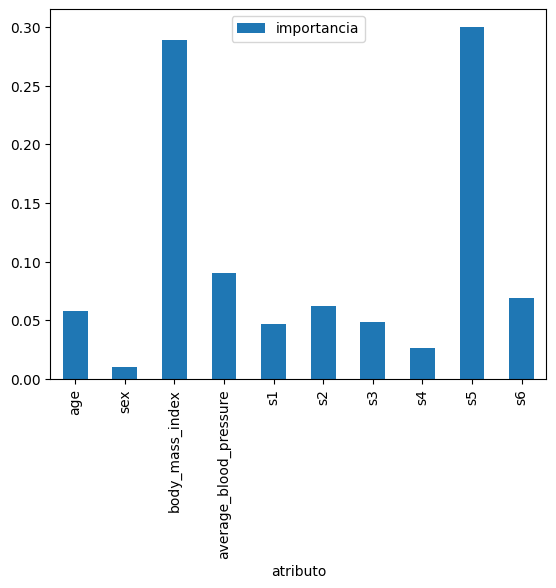

In [ ]:
X = df[df.columns.drop('disease_progression')]
y = df['disease_progression']

reg = sk.ensemble.RandomForestRegressor(n_estimators=50, n_jobs=-1)
reg.fit(X, y)

# grafico
pd.DataFrame({'atributo': reg.feature_names_in_, 'importancia': reg.feature_importances_}).plot.bar(x="atributo", y="importancia");

In [ ]:
%time sfs_forward = sk.feature_selection.SequentialFeatureSelector(reg, n_features_to_select=2, direction="forward").fit(X, y)
support = sfs_forward.get_support()
X.columns[support]
#support

CPU times: user 11.8 s, sys: 575 ms, total: 12.4 s
Wall time: 11.7 s


Index(['body_mass_index', 's5'], dtype='object')

In [ ]:
%time sfs_backward = sk.feature_selection.SequentialFeatureSelector(reg, n_features_to_select=2, direction="backward").fit(X, y)
support = sfs_backward.get_support()
X.columns[support]

CPU times: user 55.3 s, sys: 1.56 s, total: 56.9 s
Wall time: 41.2 s


Index(['body_mass_index', 's5'], dtype='object')